In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(mean = (0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225))
])

print(transform)

Compose(
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


In [16]:
import torchvision.datasets as datasets

train_dataset = datasets.CIFAR10(root="data_dir", train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root="data_dir", train=False, download=True, transform=transform)

print("CIFAR-10 Training Set: \n", train_dataset)
print("CIFAR-10 Testing Set: \n", test_dataset)

CIFAR-10 Training Set: 
 Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data_dir
    Split: Train
    StandardTransform
Transform: Compose(
               Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
           )
CIFAR-10 Testing Set: 
 Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data_dir
    Split: Test
    StandardTransform
Transform: Compose(
               Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
           )


In [17]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

first_batch = next(iter(test_loader))
images, labels = first_batch
print("Batch shape:", images.shape)
print("Testing labels:", labels)

Batch shape: torch.Size([64, 3, 224, 224])
Testing labels: tensor([3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9,
        5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9,
        7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3])


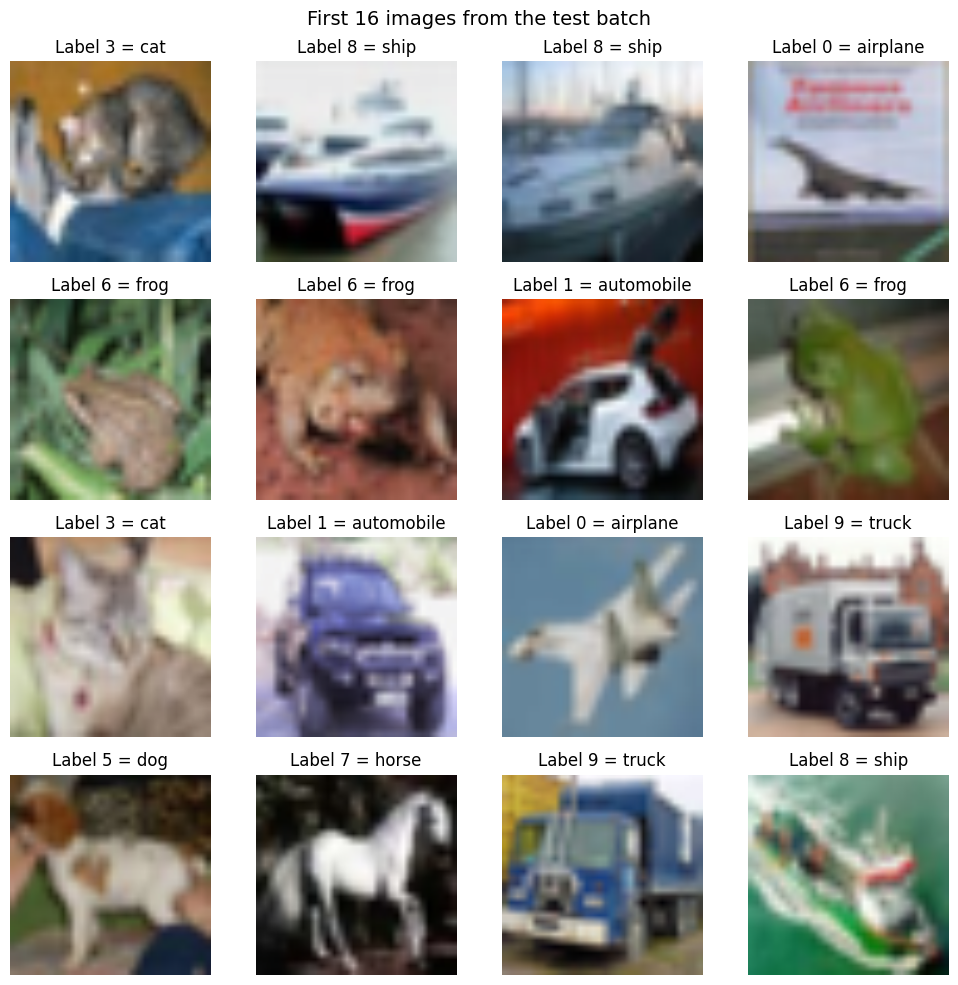

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# CIFAR-10 class names — the 10 categories the model must learn to distinguish
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def denormalize(tensor):
    """Reverse the Normalize transform so images look natural again."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()  # (C, H, W) → (H, W, C)
    img = img * std + mean                 # undo x' = (x - mean) / std
    return np.clip(img, 0, 1)             # clamp to valid [0, 1] range

# Show the first 16 images from the batch in a 4×4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 images from the test batch", fontsize=14)

for i, ax in enumerate(axes.flat):
    img = denormalize(images[i])
    ax.imshow(img)
    ax.set_title(f"Label {labels[i].item()} = {class_names[labels[i].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [24]:
import torch
import torch.nn as nn
import torchvision.models as M

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load ResNet18 with ImageNet weights first, then replace fc
model_resnet18 = M.resnet18(weights=M.ResNet18_Weights.IMAGENET1K_V1)
in_feats = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(in_feats, 10)

# Move to device and set to evaluation mode
model_resnet18 = model_resnet18.to(device).eval()

# Show output
from custom_torchinfo import custom_summary
custom_summary(model_resnet18, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [1, 3, 224, 224]          [1, 10]                   --                        True
├─Conv2d: 1-1                            [1, 3, 224, 224]          [1, 64, 112, 112]         9,408                     True
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         [1, 64, 112, 112]         128                       True
├─ReLU: 1-3                              [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
├─MaxPool2d: 1-4                         [1, 64, 112, 112]         [1, 64, 56, 56]           --                        --
├─Sequential: 1-5                        [1, 64, 56, 56]           [1, 64, 56, 56]           --                        True
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           [1, 64, 56, 56]           --                        True
│    │ 

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [1, 3, 224, 224]          [1, 10]                   --                        True
├─Conv2d: 1-1                            [1, 3, 224, 224]          [1, 64, 112, 112]         9,408                     True
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         [1, 64, 112, 112]         128                       True
├─ReLU: 1-3                              [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
├─MaxPool2d: 1-4                         [1, 64, 112, 112]         [1, 64, 56, 56]           --                        --
├─Sequential: 1-5                        [1, 64, 56, 56]           [1, 64, 56, 56]           --                        True
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           [1, 64, 56, 56]           --                        True
│    │ 